# **Python Pakcages**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# **Documentation**
[Plotly](https://plotly.com/python/)

#**Dataset**

In [ ]:
df=pd.read_csv("Pakistan Largest Ecommerce Dataset.csv")

<ipython-input-2-0b51399dc20f>:1: DtypeWarning: Columns (1,2,3,7,8,9,11,12,13,14,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("/content/drive/MyDrive/Backup-01/Literature/NU/DS/Pakistan Largest Ecommerce Dataset.csv")


In [ ]:
#number of instances/records in actual data
print(f'{df.shape[0]} Number of records in actual data')
#number of features/varaible in actual data
print(f'{df.shape[1]} Number of Features in actual data')

1048575 Number of records in actual data
26 Number of Features in actual data


In [ ]:
#check if all records are null
df.isnull().all(axis=1).sum()

464051

In [ ]:
#filtering records where any information is available
data_updated=df[df.notna().any(axis=1)]

In [ ]:
#number of instances/records in updated data
print(f'{data_updated.shape[0]} Number of records in updated data')
#number of features/varaible in updated data
print(f'{data_updated.shape[1]} Number of Features in updated data')

584524 Number of records in updated data
26 Number of Features in updated data


In [ ]:
#data types and instances information
data_updated.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584524 entries, 0 to 584523
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584509 non-null  object 
 2   created_at             584524 non-null  object 
 3   sku                    584504 non-null  object 
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  object 
 8   category_name_1        584360 non-null  object 
 9   sales_commission_code  447346 non-null  object 
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  object 
 12  Working Date           584524 non-null  object 
 13  BI Status              584524 non-null  object 
 14   MV                    584524 non-null  o

In [ ]:
#null values in data
data_updated.isnull().sum()

,0
item_id,0
status,15
created_at,0
sku,20
price,0
qty_ordered,0
grand_total,0
increment_id,0
category_name_1,164
sales_commission_code,137178


In [ ]:
#calculating % of null data
null_percentage = (data_updated.isnull().sum())/(data_updated.shape[0])*100
null_percentage

,0
item_id,0.000000
status,0.002566
created_at,0.000000
sku,0.003422
price,0.000000
qty_ordered,0.000000
grand_total,0.000000
increment_id,0.000000
category_name_1,0.028057
sales_commission_code,23.468326


In [ ]:
#droping uncessary columns
data_updated.drop(columns=['item_id','increment_id','Customer ID','Unnamed: 21','Unnamed: 22','Unnamed: 23','Unnamed: 24','Unnamed: 25'],inplace=True)

<ipython-input-10-88871be05d5c>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_updated.drop(columns=['item_id','increment_id','Customer ID','Unnamed: 21','Unnamed: 22','Unnamed: 23','Unnamed: 24','Unnamed: 25'],inplace=True)


In [ ]:
#geting information of duplicates in column
data_updated.duplicated().any()

True

In [ ]:
#columns in data
data_updated.columns

Index(['status', 'created_at', 'sku', 'price', 'qty_ordered', 'grand_total',
       'category_name_1', 'sales_commission_code', 'discount_amount',
       'payment_method', 'Working Date', 'BI Status', ' MV ', 'Year', 'Month',
       'Customer Since', 'M-Y', 'FY'],
      dtype='object')

In [ ]:
data_updated.rename(columns={'category_name_1':'Category'},inplace=True)
data_updated.columns

<ipython-input-13-e85edfdf700d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_updated.rename(columns={'category_name_1':'Category'},inplace=True)


Index(['status', 'created_at', 'sku', 'price', 'qty_ordered', 'grand_total',
       'Category', 'sales_commission_code', 'discount_amount',
       'payment_method', 'Working Date', 'BI Status', ' MV ', 'Year', 'Month',
       'Customer Since', 'M-Y', 'FY'],
      dtype='object')

# **Data cleaning & Transformation**

In [ ]:
data_transformed=data_updated.copy()

In [ ]:
data_transformed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584524 entries, 0 to 584523
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   status                 584509 non-null  object 
 1   created_at             584524 non-null  object 
 2   sku                    584504 non-null  object 
 3   price                  584524 non-null  float64
 4   qty_ordered            584524 non-null  float64
 5   grand_total            584524 non-null  float64
 6   Category               584360 non-null  object 
 7   sales_commission_code  447346 non-null  object 
 8   discount_amount        584524 non-null  float64
 9   payment_method         584524 non-null  object 
 10  Working Date           584524 non-null  object 
 11  BI Status              584524 non-null  object 
 12   MV                    584524 non-null  object 
 13  Year                   584524 non-null  float64
 14  Month                  584524 non-null  f

In [ ]:
data_transformed.isnull().sum()

,0
status,15
created_at,0
sku,20
price,0
qty_ordered,0
grand_total,0
Category,164
sales_commission_code,137178
discount_amount,0
payment_method,0


**Dealing with dates scenario**

In [ ]:
#converting working date to datetime
data_transformed['Working Date']=pd.to_datetime(data_transformed['Working Date'])

In [ ]:
#Adding weekends day
data_transformed['Weekends']=data_transformed['Working Date'].dt.dayofweek>5

**Dealing with SKU**

In [ ]:
#Getting numbers of Unique Sku
data_transformed['sku'].nunique()

84889

In [ ]:
#replacing null values in sku by unknown
data_transformed['sku'].fillna('Unknown',inplace=True)

<ipython-input-334-861c3919b669>:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
data_transformed['sku'].unique()

array(['kreations_YI 06-L',
       'kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Body Spray Free',
       'Ego_UP0017-999-MR0', ..., 'WOFVAL59D5EA84167F9-M',
       'WOFNIG5B4D7EB0E9FDD-L', 'WOFSCE5AE00357AECDE'], dtype=object)

**Dealing with status**

In [ ]:
#Getting numbers of Unique Sku
data_transformed['status'].nunique()

16

In [ ]:
#replacing null values in status by unknown
data_transformed['status'].fillna('Unknown',inplace=True)

<ipython-input-337-56c57932b65a>:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
data_transformed['status'].unique()

array(['complete', 'canceled', 'order_refunded', 'received', 'refund',
       'closed', 'fraud', 'holded', 'exchange', 'pending_paypal', 'paid',
       '\\N', 'cod', 'pending', 'Unknown', 'processing', 'payment_review'],
      dtype=object)

In [ ]:
#replacing special charatcers in status
characters_to_replace = ['!', '@', '#', '$', '%', '^', '&', '*', '(', ')', '\\']
# Replace specified characters
for char in characters_to_replace:
    data_transformed['status'] = data_transformed['status'].str.replace(char, '', regex=False)

**Dealing with commision code**

In [ ]:
#replacing missing sales commision codes by unknown
data_transformed['sales_commission_code'].fillna('Unknown',inplace=True)

<ipython-input-340-1efd838b469c>:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
data_transformed['sales_commission_code'].unique()

array(['\\N', 'R-FSD-52352', '105259', ..., 'GRS-4090974-1',
       'GRS-4090975-1', '100559728'], dtype=object)

In [ ]:
#replacing special charatcers in commision codes
characters_to_replace = ['!', '@', '#', '$', '%', '^', '&', '*', '(', ')', '\\']
# Replace specified characters
for char in characters_to_replace:
    data_transformed['sales_commission_code'] = data_transformed['sales_commission_code'].str.replace(char, '', regex=False)

**Dealing with category**

In [ ]:
#getting unique category
data_transformed['Category'].unique()

array(["Women's Fashion", 'Beauty & Grooming', 'Soghaat',
       'Mobiles & Tablets', 'Appliances', 'Home & Living',
       "Men's Fashion", 'Kids & Baby', '\\N', 'Others', 'Entertainment',
       'Computing', 'Superstore', 'Health & Sports', 'Books',
       'School & Education', nan], dtype=object)

In [ ]:
#replacing missing Category codes by unknown
data_transformed['Category'].fillna('Unknown',inplace=True)

<ipython-input-344-253133673527>:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
#replacing special charatcers in commision codes
characters_to_replace = ['!', '@', '#', '$', '%', '^', '&', '*', '(', ')', '\\']
# Replace specified characters
for char in characters_to_replace:
    data_transformed['Category'] = data_transformed['Category'].str.replace(char, '')

**Dealing with costumer since**

In [ ]:
data_transformed['Customer Since']=pd.to_datetime(data_transformed['Customer Since'])

In [ ]:
#replacing costumer since by workday date where ordered quantity > 0 and costumer since is null
data_transformed.loc[(data_transformed['qty_ordered']>0) & (data_transformed['Customer Since'].isnull()),'Customer Since']=data_transformed['Working Date']


In [ ]:
data_transformed.isnull().sum()

,0
status,0
created_at,0
sku,0
price,0
qty_ordered,0
grand_total,0
Category,0
sales_commission_code,0
discount_amount,0
payment_method,0


**Dealing with MV (Max Value)**

In [ ]:
#replacing special charatcers in commision codes
characters_to_replace = ['!', '@', '#', '$', '%', '^', '&', '*', '(', ')', '\\',"-",","]
data_transformed.loc[data_transformed[' MV '].str.strip().isin(characters_to_replace),' MV ']='0'

In [ ]:
data_transformed[' MV ']=data_transformed[' MV '].str.replace(",","").str.strip().astype('float')

In [ ]:
data_transformed.loc[data_transformed[' MV ']==0,' MV ']=data_transformed['price']*data_transformed['qty_ordered']

**Adding Price Ranges**

In [ ]:
#There may be other price ranges for higher price items, for simplicity few are created, you may add more
data_transformed['price_range'] = pd.cut(data_transformed['price'], bins=[0, 50, 100, 200, 500, 1000], labels=['0-50', '50-100', '100-200', '200-500', '500-1000'])

**Identify the numerical and categorical varaibles**

In [ ]:
# Separate numerical and categorical columns
numerical_columns = data_transformed.select_dtypes(include=['number']).columns.tolist()
categorical_columns = data_transformed.select_dtypes(include=['object', 'category']).columns.tolist()
datetime_columns = data_transformed.select_dtypes(include=['datetime']).columns.tolist()


# Create a DataFrame to display the columns in a table format
columns_dict = {
    'Numerical Columns': pd.Series(numerical_columns),
    'Categorical Columns': pd.Series(categorical_columns),
    'Datetime Columns': pd.Series(datetime_columns)
}

columns_df = pd.DataFrame(columns_dict)

# Display the DataFrame
print(columns_df)

  Numerical Columns    Categorical Columns Datetime Columns
0             price                 status     Working Date
1       qty_ordered             created_at   Customer Since
2       grand_total                    sku              NaN
3   discount_amount               Category              NaN
4               MV   sales_commission_code              NaN
5              Year         payment_method              NaN
6             Month              BI Status              NaN
7               NaN                    M-Y              NaN
8               NaN                     FY              NaN
9               NaN            price_range              NaN


**Horray.! Data is cleaned. ✅**

# **Visualization Flow**

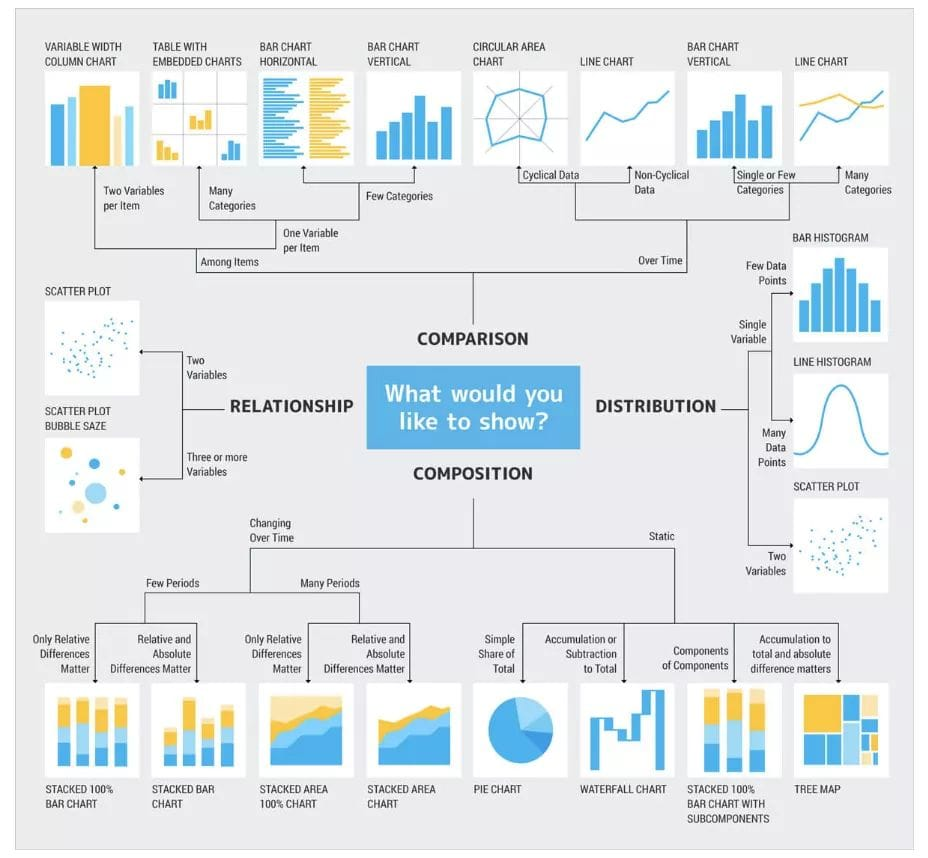

# **Data Storytelling**


> In this analysis, we dive deep into the transactional data to uncover hidden trends, correlations, and patterns that can inform business strategies and drive decision-making. By leveraging powerful visualizations, we transform raw data into a compelling narrative that connects numbers to actionable insights.

**Price and Quantity Ordered:**
We start by exploring the relationship between price and quantity ordered. The scatterplot reveals whether higher-priced products tend to have lower quantities or if there are specific price ranges where bulk orders are more frequent. This insight helps in price optimization and inventory management.

**Revenue by Product Category:**
The total revenue generated by each product category uncovers the most profitable categories. This bar chart enables businesses to focus on high-revenue categories, identify underperforming segments, and tailor marketing efforts accordingly.

**Impact of Discounts on Sales:**
A scatterplot between discount amounts and grand total illustrates how discounts influence total sales. This insight allows the business to measure the effectiveness of discount strategies, ensuring profitability without eroding margins.

**Sales Commission Performance:**
Visualizing sales commission codes against order volume provides clarity on which sales strategies (based on commission structure) result in the most sales, aiding in refining commission-based incentives for sales teams.

**Payment Method Trends by Price Range:**
Understanding how payment methods vary across different price ranges helps the business streamline payment options and enhance customer experience for different price segments.

**Sales Trends Over Time:**
Analyzing sales trends across months and years identifies seasonality in purchasing behavior, helping the business anticipate demand surges and plan promotions accordingly. This is particularly valuable for budgeting and forecasting.

**Weekends vs Weekdays Order Behavior:**
The weekend vs. weekday order distribution highlights whether weekends see a surge in sales, aiding in optimizing workforce allocation, marketing campaigns, and promotions for specific days.

**Customer Acquisition Over Time:**
The line plot on customer acquisition shows how the customer base has expanded over time. This insight helps evaluate customer growth strategies and the impact of marketing campaigns on customer acquisition.

**Order Volume by Working Dates:**
Tracking orders by working dates helps in understanding if there are specific working days or periods that lead to more transactions, helping adjust operational planning and staffing.

**Category-wise Order Quantity Variations:**
The variability in order quantities across different categories provides insights into customer preferences. Categories with higher average order quantities might warrant more stock, while lower-quantity categories might need product bundling or promotions.

**High-Value Orders by Category:**
Analyzing the distribution of high-value orders across categories helps businesses focus on promoting products with high margins, increasing the potential for profit.

**Sales Performance by Fiscal Year:**
The revenue generated across different fiscal years can signal the overall growth trajectory of the business. This helps leadership track performance over time and make long-term strategic decisions.

**Average Order Value Trends:**
Tracking average order value over time indicates whether the company is improving at upselling or cross-selling products. This trend can shape future pricing strategies and product bundling.

**Monthly Revenue Peaks:**
Identifying the months that generate the highest revenue helps pinpoint high-demand periods and guide marketing budgets, stock planning, and seasonal sales strategies.

**Cleaned Data**

In [ ]:
#clean data
data_clean=data_transformed.copy()

In [ ]:
data_clean.columns

Index(['status', 'created_at', 'sku', 'price', 'qty_ordered', 'grand_total',
       'Category', 'sales_commission_code', 'discount_amount',
       'payment_method', 'Working Date', 'BI Status', ' MV ', 'Year', 'Month',
       'Customer Since', 'M-Y', 'FY', 'Weekends', 'price_range'],
      dtype='object')

**Summarize Total Revenue, Total Orderded and discounts offered each catgeory**

In [ ]:
revenue_quantity=data_clean.groupby('Category').agg(
                  Revenue_Millions=('grand_total',lambda x:round(x.sum()/ 1000000,2)),
                  Total_Quantity=('qty_ordered','sum'),
                  Total_Discounts_Millions=('discount_amount',lambda x: round(abs(x).sum()/1000000,2))).sort_values('Revenue_Millions',ascending=False).reset_index()

**Revenue trend over fiscal years**

In [ ]:
fy_sales = data_clean.groupby(['Category','FY']).agg(
                  Revenue_Millions=('grand_total',lambda x:round(x.sum()/ 1000000,2)),
                  Total_Quantity=('qty_ordered','sum')).reset_index()

**Summarize Number Of Order Over Time**

In [ ]:
orders_by_date = data_clean.groupby(['Working Date','Category'])['sku'].count().reset_index(name='Order Count')

# **Matplotlib**




Relationship between two variables


*   Comparing two numerical variables
*   Scatter plot is best fit to find relationship
*   Check visulaization flow diagram



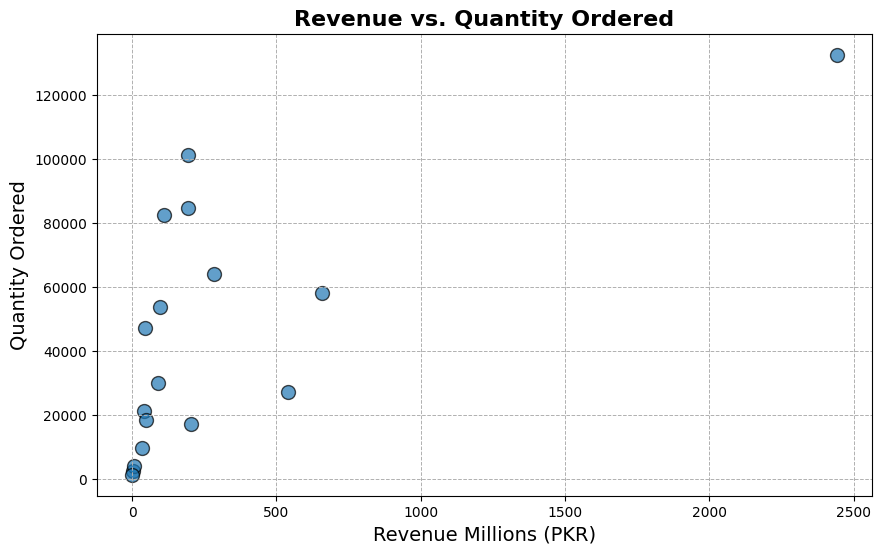

In [ ]:
plt.figure(figsize=(10, 6))  # Set figure size
#comparing the total revenue with quantity ordered
plt.scatter(revenue_quantity['Revenue_Millions'],revenue_quantity['Total_Quantity'], s=100, edgecolor='black', alpha=0.7)
# Add title and labels with formatting
plt.title('Revenue vs. Quantity Ordered', fontsize=16, fontweight='bold')
plt.xlabel('Revenue Millions (PKR)', fontsize=14)
plt.ylabel('Quantity Ordered', fontsize=14)
# Add gridlines
plt.grid(True, which='major', linestyle='--', linewidth=0.7)

# Show plot
plt.show()

Relationship between more than two variables


*   Comparing two numerical variables including the effect of third varaible.
*   Scatter plot is best fit to find relationship
*   Check visulaization flow diagram
*   Use size, color or shape or increase dimension of plot i:e (3D)
*   Matplotlib requires numbers assign to categorical variable so can map unqiue color when varaible used as a comparison

In [ ]:
# Assigning numbers to categories
categories = revenue_quantity['Category'].unique()
#looping throug each category and assign numbers
color_map = {category: i for i, category in enumerate(categories)}
#adding category color unique numbers
revenue_quantity['Category_Color'] = revenue_quantity['Category'].map(color_map)

In [ ]:
 #get list of color maps
 print(list(plt.colormaps))

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 'turbo_r', 'Blues_r', 'BrBG_r', 'BuGn_r', 'BuPu_r', 'CMRmap_r', 'GnBu_r', 'G

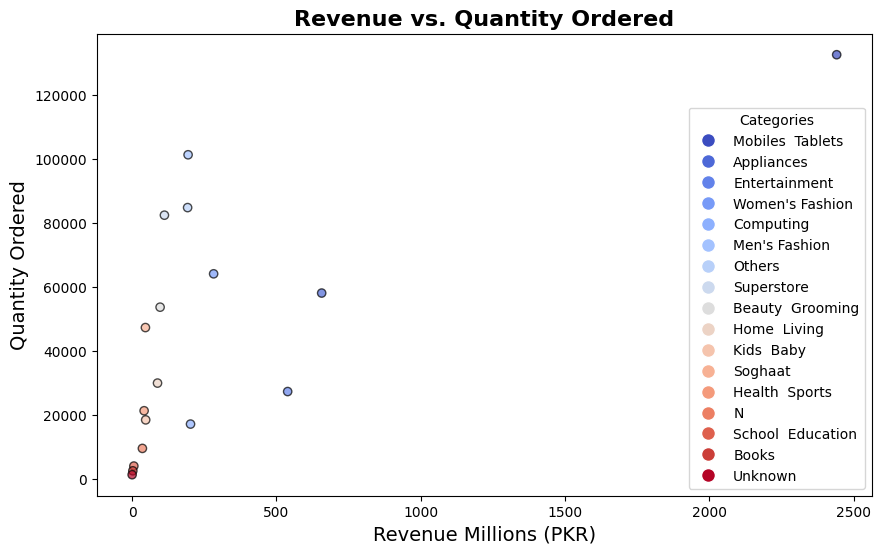

In [ ]:
# Create a colormap with unique colors
cmap = plt.get_cmap('coolwarm', len(categories))

# Create the scatter plot
plt.figure(figsize=(10, 6))  # Set figure size

# Plot scatter with colors based on category index
plt.scatter(
    revenue_quantity['Revenue_Millions'],
    revenue_quantity['Total_Quantity'],
    c=revenue_quantity['Category_Color'],  # Use the numeric color mapping
    cmap=cmap,  # Use the colormap
    edgecolor='black',
    alpha=0.7
)

# Add title and labels with formatting
plt.title('Revenue vs. Quantity Ordered', fontsize=16, fontweight='bold')
plt.xlabel('Revenue Millions (PKR)', fontsize=14)
plt.ylabel('Quantity Ordered', fontsize=14)

# Create custom legend for categories
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(i / len(categories)), markersize=10) for i in range(len(categories))]
plt.legend(handles, categories, title='Categories')

# Add gridlines
plt.grid(True, which='minor', linestyle='--', linewidth=0.7)

# Show plot
plt.show()

Relationship between two variables.


1.   Comparing numercial and categorical varaible
2.   Vertical Bar chart (Categorical on x-axis)
3.   Horizontal bar chart (Categorical on y-axis)
4.   Variable width column chart ( using another numerical varible to see impact)


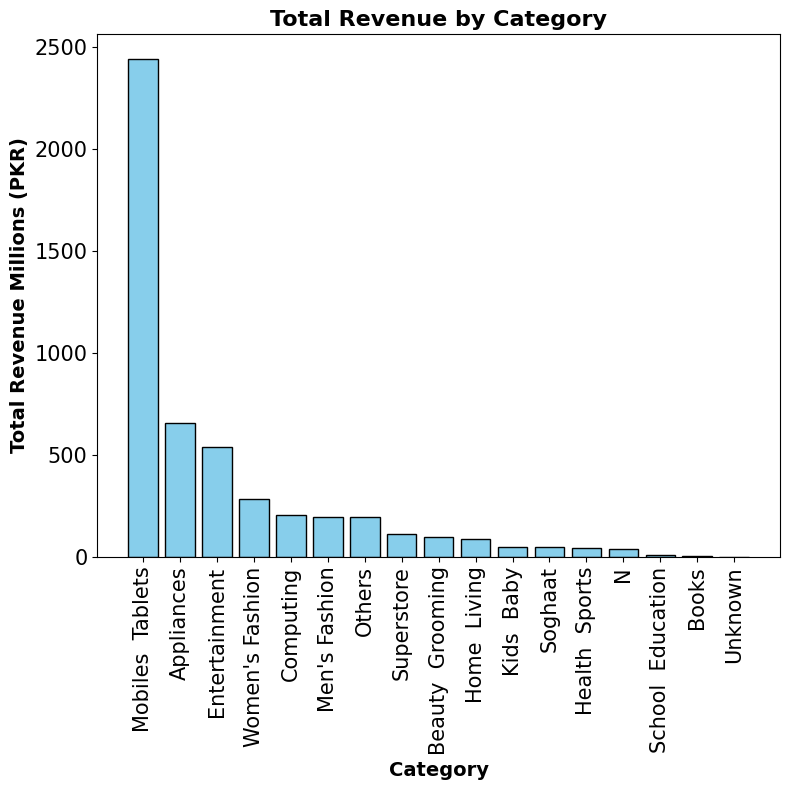

In [ ]:
# Set the figure size
plt.figure(figsize=(8, 8))

# Create a vertical bar plot, category on x-axis, for horizontal swap the postion of category and revenue in bar function
plt.bar(revenue_quantity['Category'],revenue_quantity['Revenue_Millions'], color='skyblue', edgecolor='black')

# Add title and labels
plt.title('Total Revenue by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue Millions (PKR)', fontsize=14, fontweight='bold')

# Set x-ticks and y-ticks to improve clarity
plt.xticks(fontsize=15,rotation=90)  # Set font size for x-ticks
plt.yticks(fontsize=15)  # Set font size for y-ticks

# Use tight layout to adjust spacing
plt.tight_layout()

# Show the plot
plt.show()

Variation of bar chart


1.   Adding dicount offers to see if there is any impact on total revenue
2.   Varaible width bar chart (See Visualization Flow)



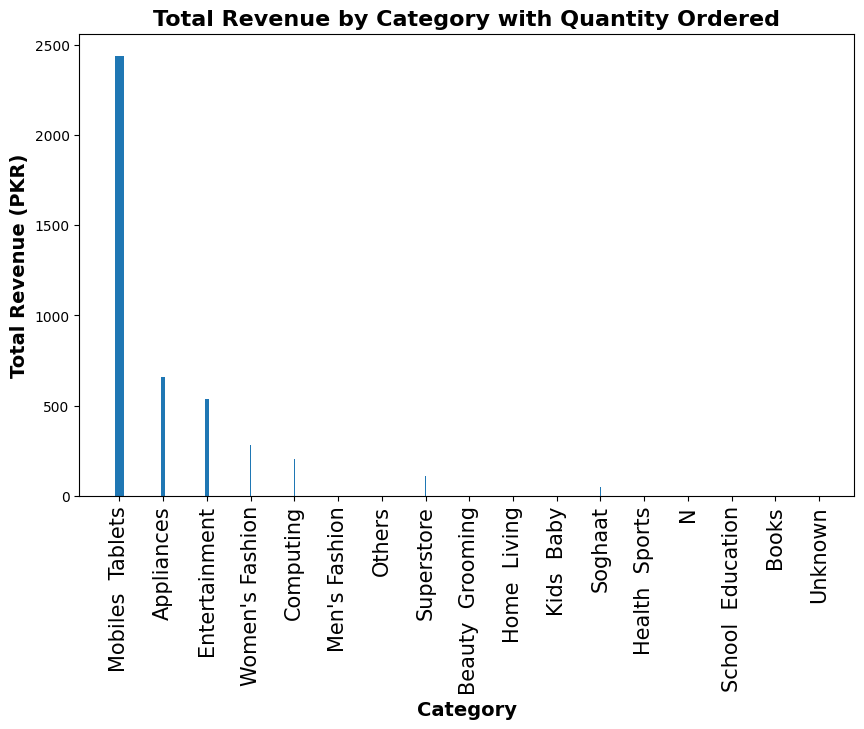

In [ ]:
categories = revenue_quantity['Category']
revenue = revenue_quantity['Revenue_Millions']
discounts = revenue_quantity['Total_Discounts_Millions']

# Calculate bar widths based on Discounts and Normalize the discounts for bar width
bar_widths = np.array(discounts) / sum(discounts) * 0.5  # Adjust the multiplier for scaling

#set figuresize
plt.figure(figsize=(10, 6))

#plot bar graph
plt.bar(categories, revenue, width=bar_widths)

# Add title and labels
plt.title('Total Revenue by Category with Quantity Ordered', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue (PKR)', fontsize=14, fontweight='bold')

# Set x-ticks and y-ticks to improve clarity
plt.xticks(fontsize=15,rotation=90)  # Set font size for x-ticks
plt.yticks(fontsize=10)  # Set font size for y-ticks

plt.show()

Analysis of payment metod share in tarnsactions, pie chart is better option

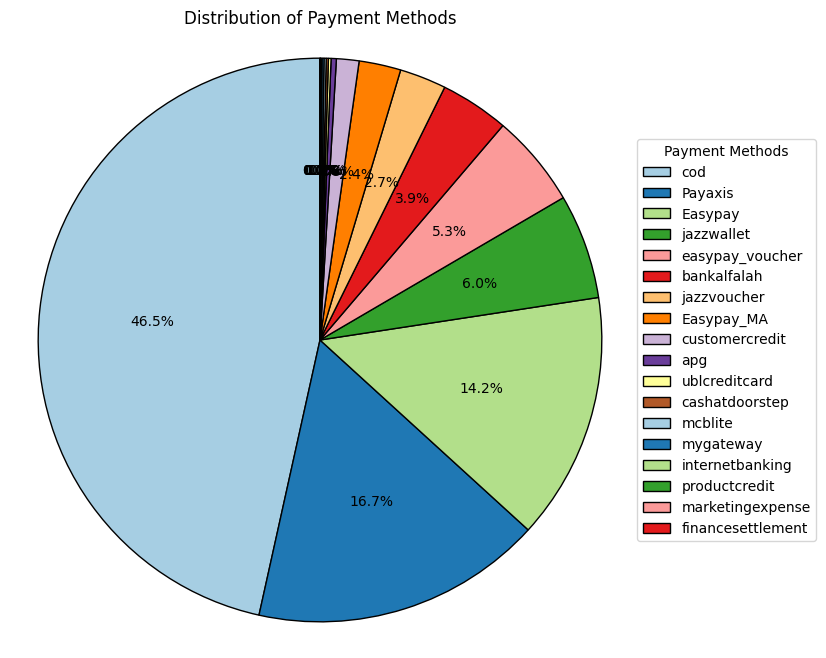

In [ ]:
# Count occurrences of each payment method
payment_counts = data_clean['payment_method'].value_counts()

# Define colors
colors = plt.cm.Paired.colors  # Colormap for the pie chart

# Create the pie chart
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(payment_counts,
                                   labels=None,  # Set labels to None to use legends instead
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=colors,
                                   wedgeprops={'edgecolor': 'black'})  # Border for better visuals

# Add a title
plt.title('Distribution of Payment Methods')

# Equal aspect ratio ensures that pie is drawn as a circle.
plt.axis('equal')

# Create custom legend using payment method labels
plt.legend(wedges, payment_counts.index, title="Payment Methods", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# Show the pie chart
plt.show()

Analyze the Revenue over FY

<Figure size 1000x600 with 0 Axes>

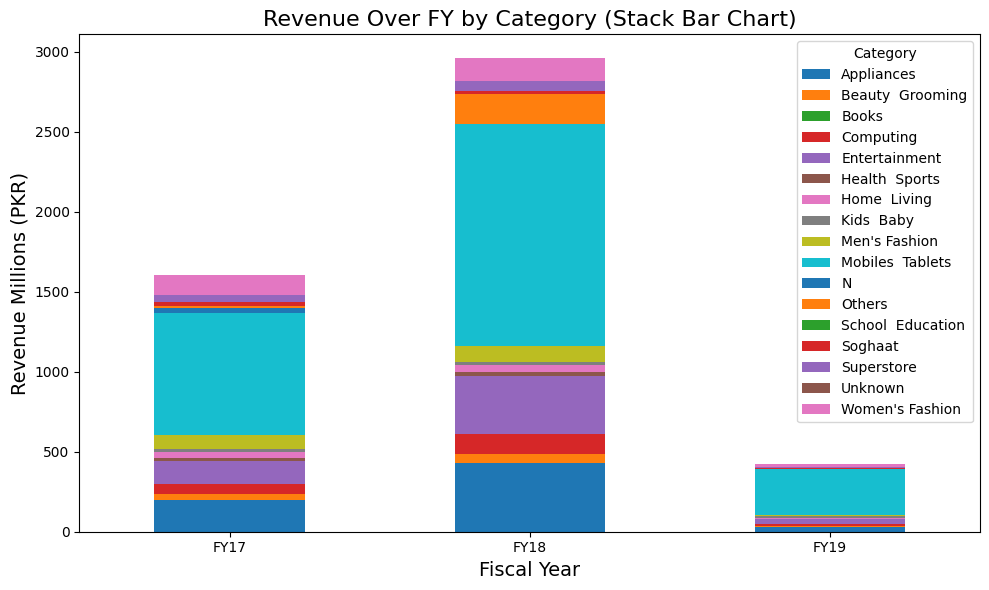

In [ ]:
pivot_df = fy_sales.pivot(index='FY', columns='Category', values='Revenue_Millions').fillna(0)

# Create the stacked bar chart
plt.figure(figsize=(10, 6))
pivot_df.plot(kind='bar', stacked=True, figsize=(10, 6))

# Add title and labels
plt.title('Revenue Over FY by Category (Stack Bar Chart)', fontsize=16)
plt.xlabel('Fiscal Year', fontsize=14)
plt.ylabel('Revenue Millions (PKR)', fontsize=14)

# Adjust the layout for better readability
plt.xticks(rotation=0)  # Rotate x-axis labels to horizontal

# Add a legend
plt.legend(title='Category')

# Show the plot
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

<Figure size 1000x600 with 0 Axes>

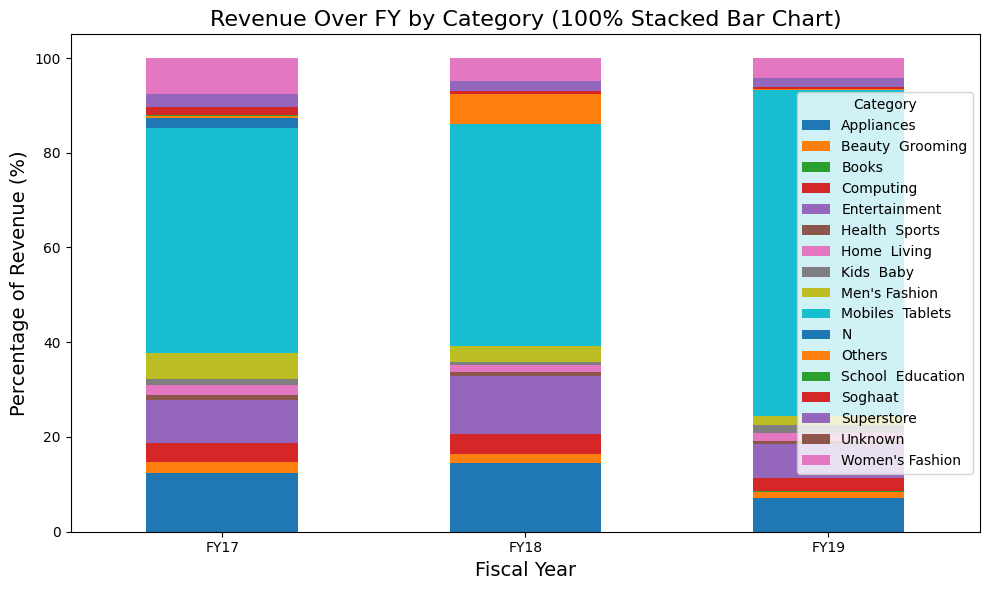

In [ ]:
# Pivot the DataFrame to get categories as columns
pivot_df = fy_sales.pivot(index='FY', columns='Category', values='Revenue_Millions').fillna(0)

# Normalize the pivoted DataFrame to get percentages
pivot_df_normalized = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# Create the 100% stacked bar chart
plt.figure(figsize=(10, 6))
pivot_df_normalized.plot(kind='bar', stacked=True, figsize=(10, 6))

# Add title and labels
plt.title('Revenue Over FY by Category (100% Stacked Bar Chart)', fontsize=16)
plt.xlabel('Fiscal Year', fontsize=14)
plt.ylabel('Percentage of Revenue (%)', fontsize=14)

# Adjust the layout for better readability
plt.xticks(rotation=0)  # Rotate x-axis labels to horizontal

# Add a legend
plt.legend(title='Category')

# Show the plot
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

Analyze number of orders by date

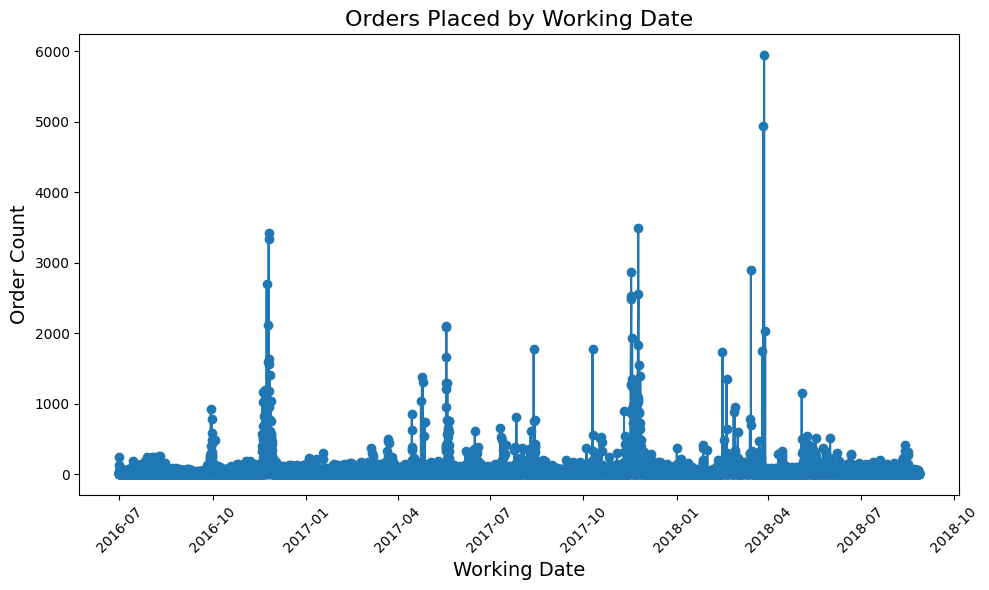

In [ ]:
# Create a line plot
plt.figure(figsize=(10, 6))
plt.plot(orders_by_date['Working Date'], orders_by_date['Order Count'], marker='o', linestyle='-')

# Add title and labels
plt.title('Orders Placed by Working Date', fontsize=16)
plt.xlabel('Working Date', fontsize=14)
plt.ylabel('Order Count', fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

Analyze number of orders by date per category

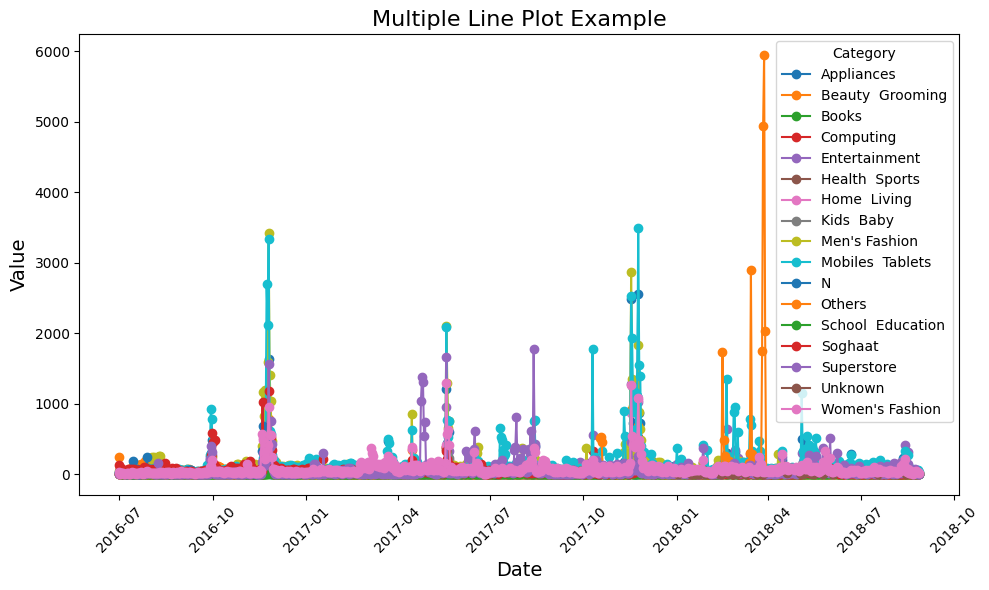

In [ ]:
# Pivot the DataFrame to get categories as columns
pivot_df = orders_by_date.pivot(index='Working Date', columns='Category', values='Order Count')

# Create a line plot
plt.figure(figsize=(10, 6))
plt.plot(pivot_df.index, pivot_df, marker='o')

# Set title and labels
plt.title('Multiple Line Plot Example', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Value', fontsize=14)

# Add legend
plt.legend(pivot_df.columns, title='Category')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

# **Seaborn**

Relationship between two variables
*   Visuals are same as matplotlib
*   Difference is just how data is provided



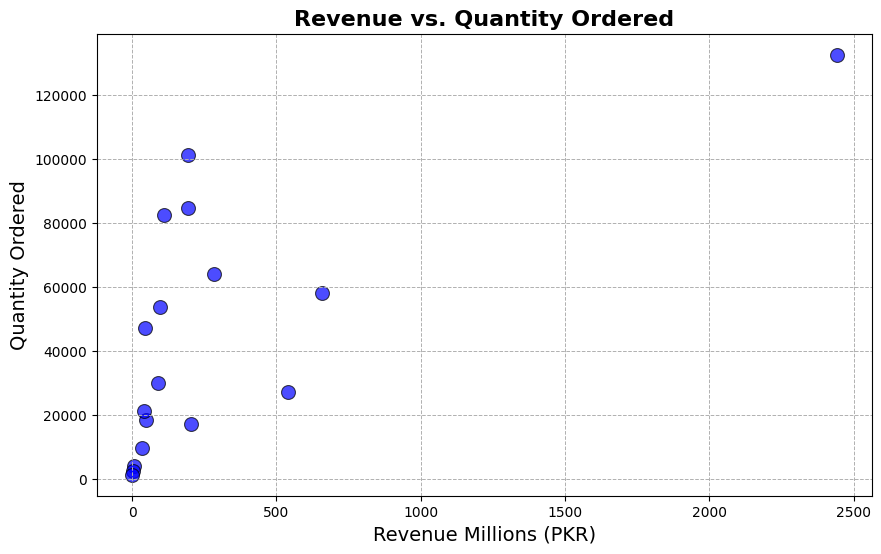

In [ ]:
# Set figure size
plt.figure(figsize=(10, 6))
# Seaborn satterplot, requires data farme to be passed and the axis of varaibles define in x and y, the name should be same as in dataframe
sns.scatterplot(x='Revenue_Millions', y='Total_Quantity', data=revenue_quantity, color='blue', s=100, edgecolor='black', alpha=0.7)

# Add title and labels with formatting
plt.title('Revenue vs. Quantity Ordered', fontsize=16, fontweight='bold')
plt.xlabel('Revenue Millions (PKR)', fontsize=14)
plt.ylabel('Quantity Ordered', fontsize=14)

# Add gridlines
plt.grid(True, which='major', linestyle='--', linewidth=0.7)

# Show plot
plt.show()

Relationship with more than two variable


*   Scatter plot in seaborn dont requires color codes
*   Category variable can be passed in hue



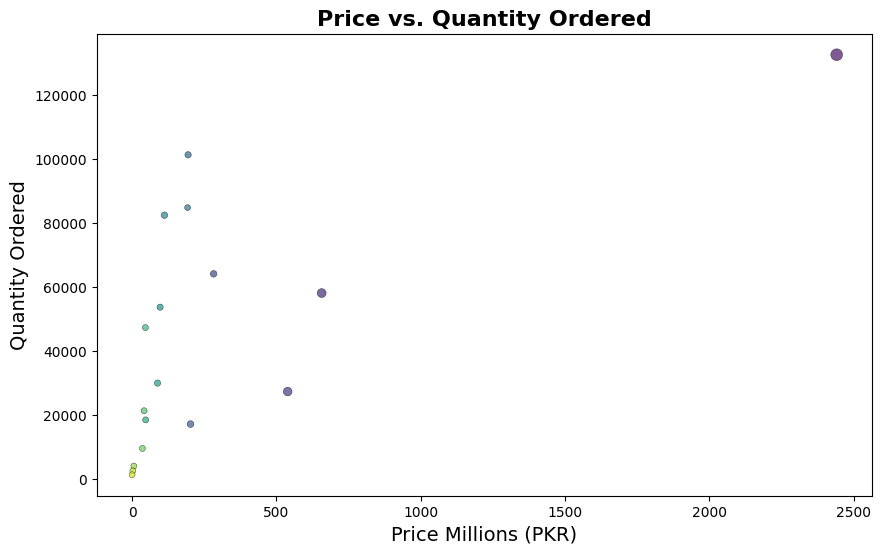

In [ ]:
 # Set figure size
plt.figure(figsize=(10, 6))
# Comparison between revenue and total quantity using categrories as a comparison, also discount amount is added which may act as a fourst variable
scatter=sns.scatterplot(
    x='Revenue_Millions',
    y='Total_Quantity',
    data=revenue_quantity,
    hue='Category',  # Use hue for categorical coloring
    size='Total_Discounts_Millions',  # Range for marker sizes
    edgecolor='black',
    alpha=0.7,
    palette='viridis', # You can choose a different palette if needed
    legend=False
)

# Manually create a legend for 'Category', this function can be use to create legend if more than three variables are used for comparison
#handles, labels = scatter.get_legend_handles_labels()  # Get the handles and labels from the hue
#plt.legend(handles[:len(price_quantity['Category'].unique())],  # Keep only the 'hue' handles
#           labels[:len(price_quantity['Category'].unique())],  # Keep only the 'hue' labels
#           title='Category', loc='upper right', fontsize=12)  # Customize legend

# Add title and labels with formatting
plt.title('Price vs. Quantity Ordered', fontsize=16, fontweight='bold')
plt.xlabel('Price Millions (PKR)', fontsize=14)
plt.ylabel('Quantity Ordered', fontsize=14)

# Add gridlines
plt.grid(True, which='minor', linestyle='--', linewidth=0.7)

# Show plot
plt.show()

When there are many categories and you want to analyse each individually, use facet graph. Remember we did this lab-01 by combining all visuals on subplot using matplotlib.

Text(0.5, 0.98, 'Scatter Plot: Relationship Between Two Variables by Category')

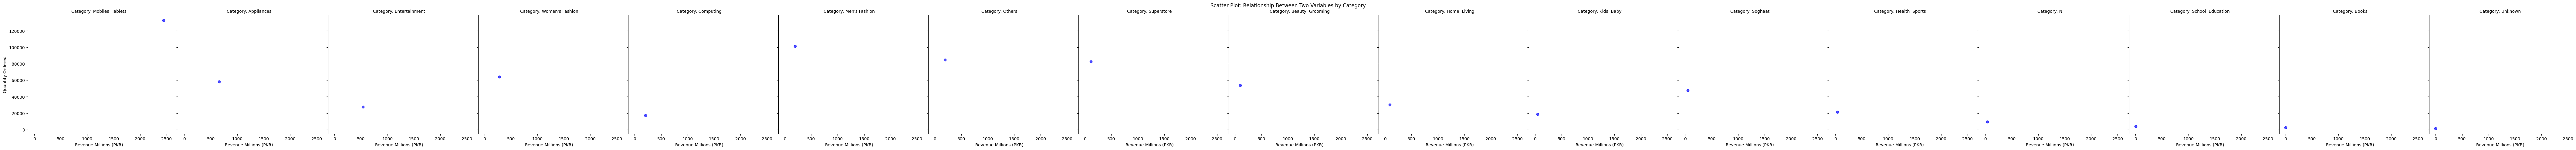

In [ ]:
# Create a facet grid using seaborn
g = sns.FacetGrid(revenue_quantity, col='Category', height=5)
g.map(plt.scatter, 'Revenue_Millions', 'Total_Quantity', color='blue', alpha=0.7)
g.set_axis_labels('Revenue Millions (PKR)', 'Quantity Ordered')
g.set_titles(col_template='Category: {col_name}')
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Scatter Plot: Relationship Between Two Variables by Category')

Relationship between two varaibles.

1.  Comparing numercial and categorical varaible
2.  Vertical Bar chart (Categorical on x-axis)
3.  Horizontal bar chart (Categorical on y-axis)
4.  Variable width bar chart (using other numercial variable to see effect)





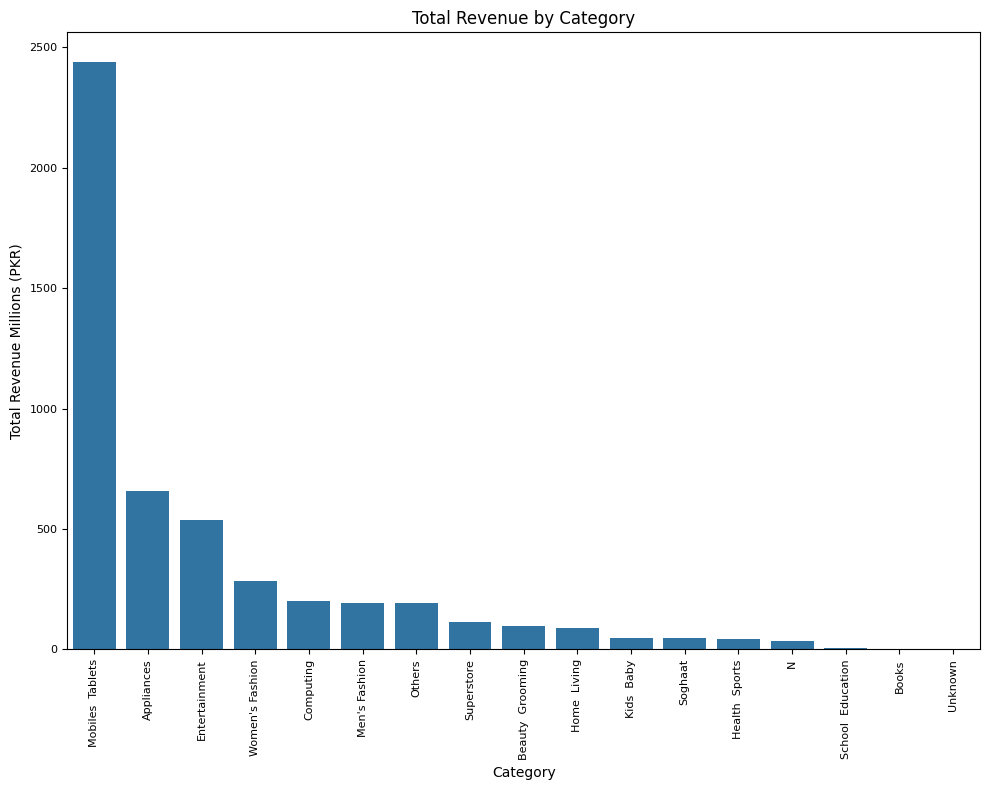

In [ ]:
# Increase the figure width for better spacing
plt.figure(figsize=(10, 8))
#Create a vertical bar plot, category on x-axis, for horizontal swap the postion of category and revenue in bar function
sns.barplot(x='Category', y='Revenue_Millions', data=revenue_quantity,errorbar=None)
plt.title('Total Revenue by Category')
#Set x & y labele
plt.xlabel('Category')
plt.ylabel('Total Revenue Millions (PKR)')
# Set x-ticks and y-ticks to improve clarity
plt.xticks(fontsize=8, rotation=90)  # Rotate and adjust padding
plt.yticks(fontsize=8)
# Use tight layout to adjust spacing
plt.tight_layout()
plt.show()

Variation of bar chart

1. Adding dicount offers to see if there is any impact on total revenue
2. Varaible width bar chart (See Visualization Flow)




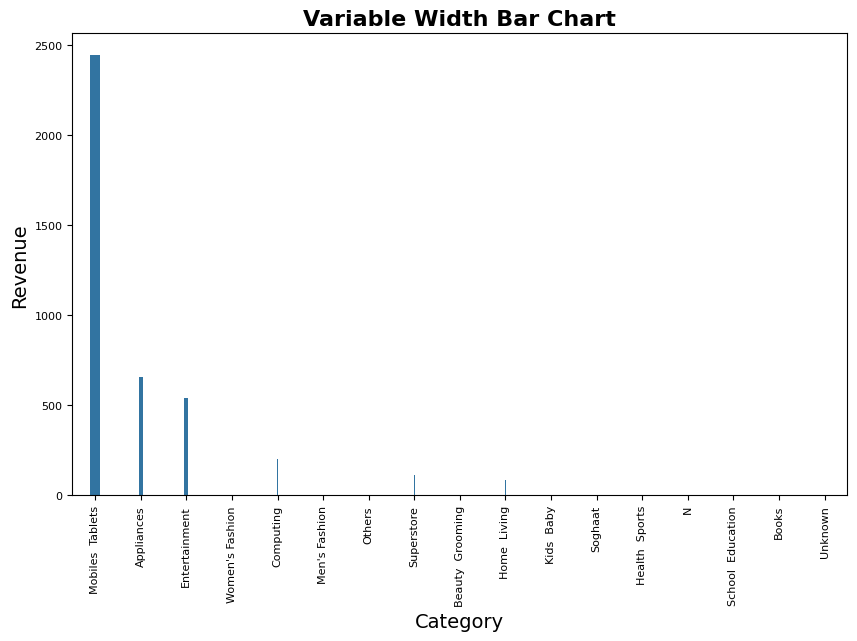

In [ ]:
# Calculate bar widths based on Discounts
discounts = revenue_quantity['Total_Discounts_Millions']

# Normalize the discounts for bar width
bar_widths = np.array(discounts) / sum(discounts) * 0.5  # Adjust the multiplier for scaling

# Create a base bar plot with Seaborn
plt.figure(figsize=(10, 6))

sns.barplot(x='Category', y='Revenue_Millions',width=bar_widths, data=revenue_quantity,errorbar=None)

# Set x-ticks and y-ticks to improve clarity
plt.xticks(fontsize=8, rotation=90)  # Rotate and adjust padding
plt.yticks(fontsize=8)

# Add title and labels
plt.title('Variable Width Bar Chart', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=14)
plt.ylabel('Revenue', fontsize=14)


# Show plot
plt.show()

Analyze numbers of orders by dates


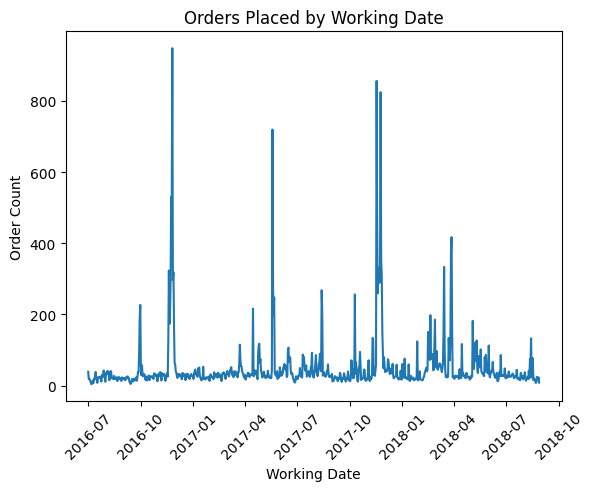

In [ ]:
sns.lineplot(x='Working Date', y='Order Count', data=orders_by_date,errorbar=None)
plt.title('Orders Placed by Working Date')
plt.xticks(rotation=45)
plt.show()

# **Plotly**

Relationship between two numerical variables



In [ ]:
#Comparing revenue with grand total, however hover_data is just to add more information that is not comparison
fig1 = px.scatter(
    revenue_quantity,  # Your dataframe
    x='Revenue_Millions',
    y='Total_Quantity',
    title='Revenue vs Quantity Ordered',
    labels={'Revenue': 'Revenue Millions (PKR)', 'Total_Quantity': 'Quantity Ordered'},  # Axis labels
    hover_data=['Category'], #Adding information about other varaible, that is different than comparison, plotly just make charts interactive
)

# Customize the layout and appearance
fig1.update_traces(marker=dict(size=10, color='blue', line=dict(width=1, color='black'), opacity=0.7))

# Add gridlines and adjust figure size
fig1.update_layout(
    xaxis=dict(showgrid=True, gridwidth=0.5, gridcolor='LightGray'),
    yaxis=dict(showgrid=True, gridwidth=0.5, gridcolor='LightGray'),
    width=800, height=600  # Set figure size
)

# Show plot
fig1.show()

Relationship between more than two variables

In [ ]:
# Scatterplot using Plotly
fig = px.scatter(
    revenue_quantity,
    x='Revenue_Millions',
    y='Total_Quantity',
    color='Category',  # Use color for categorical coloring
    color_continuous_scale='Viridis', #Set color schemes, you may use different
    size='Total_Discounts_Millions',  # Maximum size of the markers
    title='Revenue Millions vs. Quantity Ordered',  # Title of the plot
    labels={'Revenue': 'Revenue Million (PKR)', 'Total_Quantity': 'Quantity Ordered'},  # Axis labels
)

# Update layout for better formatting
fig.update_layout(
    title_font_size=16,  # Title font size
    xaxis_title='Revenue Million (PKR)',  # X-axis title
    yaxis_title='Quantity Ordered',  # Y-axis title
    showlegend=True,  # Show legend
    legend_title='Category',  # Legend title
)

# Show plot
fig.show()

Relationship of numerical vs categorical (Bar chart)

In [ ]:
# Create horizontal bar chart
fig = px.bar(revenue_quantity.sort_values('Revenue_Millions',ascending=True), x='Revenue_Millions', y='Category')

# Update layout
fig.update_layout(
    title='Revenue vs. Quantity Ordered',
    xaxis_title='Categories',
    yaxis_title='Revenue Million (PKR)',
    yaxis_tickfont=dict(size=10),
    xaxis_tickfont=dict(size=10)
)

# Show the plot
fig.show()

In [ ]:
# Create vertical bar chart
fig = px.bar(revenue_quantity.sort_values('Revenue_Millions',ascending=False), x='Category', y='Revenue_Millions')

# Update layout
fig.update_layout(
    title='Revenue vs. Quantity Ordered',
    xaxis_title='Categories',
    yaxis_title='Revenue Million (PKR)',
    yaxis_tickfont=dict(size=10),
    xaxis_tickfont=dict(size=10)
)

# Show the plot
fig.show()

Relationship of category with revenue including discount impact (Variable width bar chart)

In [ ]:
# Calculate bar widths based on Discounts
discounts = revenue_quantity['Total_Discounts_Millions']

# Normalize the discounts for bar width
bar_widths = np.array(discounts) / sum(discounts) * 0.5  # Adjust the multiplier for scaling

# Create variable width bar chart
fig = px.bar(revenue_quantity, x='Category', y='Revenue_Millions', color='Category')

# Update the bar width
fig.update_traces(width=bar_widths)

# Update layout
fig.update_layout(
    title='Revenue Millions (PKR) in each category including discount impact',
    xaxis_title='Categories',
    yaxis_title='Revenue Million (PKR)',
    yaxis_tickfont=dict(size=10),
    xaxis_tickfont=dict(size=10)
)

# Show the plot
fig.show()

Accumultaion to total, treemaps are good to see big picture, like price range and paymeent method

In [ ]:
# Count occurrences of each combination and replace zero counts with a small value
treemap_data = data_clean.groupby(['price_range', 'payment_method'],observed=False).size().reset_index(name='Transactions')
treemap_data['Transactions'] = treemap_data['Transactions'].replace(0, 0.001) # Replace zero counts to avoid division by zero

# Create a treemap
fig = px.treemap(treemap_data,
                 path=['price_range', 'payment_method'],  # Hierarchical structure
                 values='Transactions',  # Size of the rectangles
                 title='Treemap of Price Range by Payment Method',
                 color='Transactions',  # Color based on count
                 color_continuous_scale='Viridis'  # Color scale
                )

# Show the treemap
fig.show()

/usr/local/lib/python3.10/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/local/lib/python3.10/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Analysis of payment method share in tarnsactions, pie chart is better option

In [ ]:
# Count occurrences of each payment method
payment_counts = data_clean['payment_method'].value_counts().reset_index(name='Transactions')
# Create a pie chart using Plotly Express
fig = px.pie(payment_counts,
             values='Transactions',
             names='payment_method',
             title='Distribution of Payment Methods')

# Show the pie chart
fig.show()

Abalyse the revenue over fiscal years

In [ ]:
fig = px.bar(fy_sales, x='FY', y='Revenue_Millions', color='Category', title='Revenue Over FY by Category (Stack Bar Chart)')

# Update layout for better readability (optional)
fig.update_layout(
    xaxis_title='Fiscal Year',
    yaxis_title='Revenue Millions (PKR)',
    bargap=0.2,  # Adjust the gap between bars
)

# Show the plot
fig.show()

In [ ]:
# Calculate the total sales for each 'FY' to normalize
fy_sales['Total_Sales'] = fy_sales.groupby('FY')['Revenue_Millions'].transform('sum')

# Calculate the percentage contribution of each category
fy_sales['Percentage'] = fy_sales['Revenue_Millions'] / fy_sales['Total_Sales'] * 100

# Create the 100% stacked bar chart
fig = px.bar(
    fy_sales,
    x='FY',
    y='Percentage',  # Use the calculated percentage
    color='Category',
    title='Revenue Over FY by Category (100% Stack Bar Chart)',
)

# Update layout for better readability
fig.update_layout(
    xaxis_title='FY',
    yaxis_title='Percentage of Sales',
    bargap=0.2,  # Adjust the gap between bars
)

# Show the plot
fig.show()


Analyze the number of orders by date

In [ ]:
# Create a line plot
fig = px.line(orders_by_date, x='Working Date', y='Order Count', title='Orders By Date', markers=True)

# Update layout for better readability
fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Order Placed',
    xaxis_tickformat='%Y-%m-%d'  # Format the date on the x-axis
)

# Show the plot
fig.show()

Analyze the number of orders by date for each category

In [ ]:
# Create a line plot
fig = px.line(orders_by_date, x='Working Date', y='Order Count',color='Category', title='Orders By Date Per Category', markers=True)

# Update layout for better readability
fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Order Placed',
    xaxis_tickformat='%Y-%m-%d'  # Format the date on the x-axis
)

# Show the plot
fig.show()

[Data Set Reference](https://www.kaggle.com/zusmani)